# Simple Linear Regression – Marketing ROI Analysis

## Objective

The objective of this project is to identify the marketing channel that has the strongest relationship with sales using Simple Linear Regression. The analysis includes data exploration, visualization, model building, evaluation, and business recommendations.

# Introduction

Marketing organizations invest heavily in multiple advertising channels to increase product sales. However, determining which advertising medium contributes most to sales is essential for maximizing return on investment (ROI).

This project applies Simple Linear Regression to identify the marketing channel with the strongest influence on sales. The analysis includes data cleaning, exploratory data analysis (EDA), regression modeling, model evaluation, assumption checking, and business recommendations.

In [1]:
#Import libraries
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from io import StringIO

In [2]:
#importing sklearn model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import scipy.stats as stats

In [3]:
#importing data set using pandas
df = pd.read_csv("market_sales_data.csv")

In [4]:
#Checking and Exploring data
df.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [5]:
df.shape

(4572, 4)

In [6]:
df.columns

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [8]:
#checking summary stat
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


### Data Cleaning

Before model development, the dataset was inspected for missing values, duplicate observations, and incorrect data types.

Rows containing missing values were removed because they represented a very small proportion of the dataset and were unlikely to affect the model performance.

In [9]:
#Data cleaning_ checking for missing data
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [10]:
# Checking for Duplicate
df.duplicated().sum()

np.int64(0)

In [11]:
#removing duplicate if any
df.drop_duplicates(inplace=True)

In [12]:
#checking data type. all avribles shoild be numeric
df.dtypes

TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

In [13]:
#Removing the missing value 
df.dropna(inplace=True)

In [14]:
# recheching the shape
df.shape

(4546, 4)

Exploratory Data Analysis (EDA)
We'll investigate:

Distribution of each variable
Correlation matrix
Pairwise relationships
Identify the strongest predictor of Sales

## Exploratory Data Analysis

The purpose of exploratory data analysis (EDA) is to understand the distribution of variables and identify relationships between marketing channels and sales.
The histograms show the distribution of each marketing variable and Sales. Most variables appear reasonably continuous without extreme skewness, suggesting they are suitable for regression analysis.

<Figure size 1200x800 with 0 Axes>

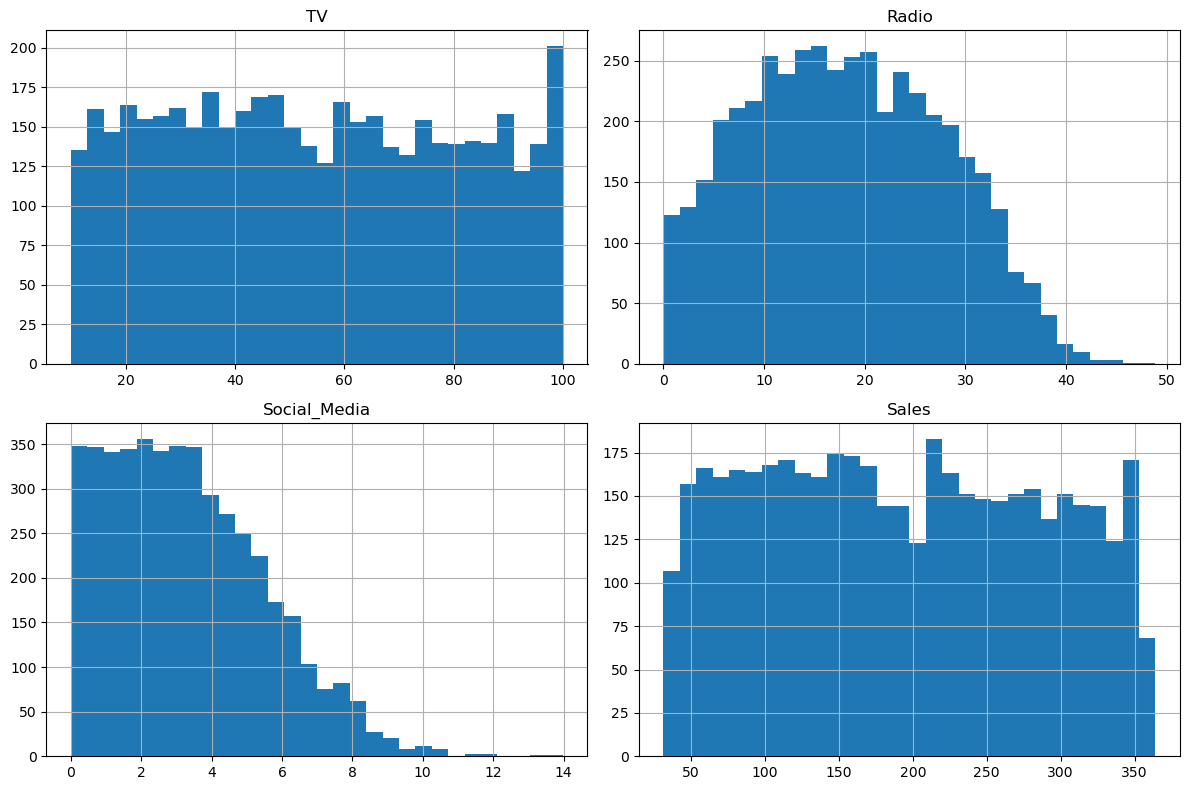

In [15]:
#Histogram
plt.figure(figsize=(12,8))

df.hist(bins=30, figsize=(12,8))

plt.tight_layout()

plt.show()

### Interpretation

The histograms indicate that all variables are continuous and approximately symmetric, with no evidence of severe skewness. This suggests that the variables are suitable for linear regression.

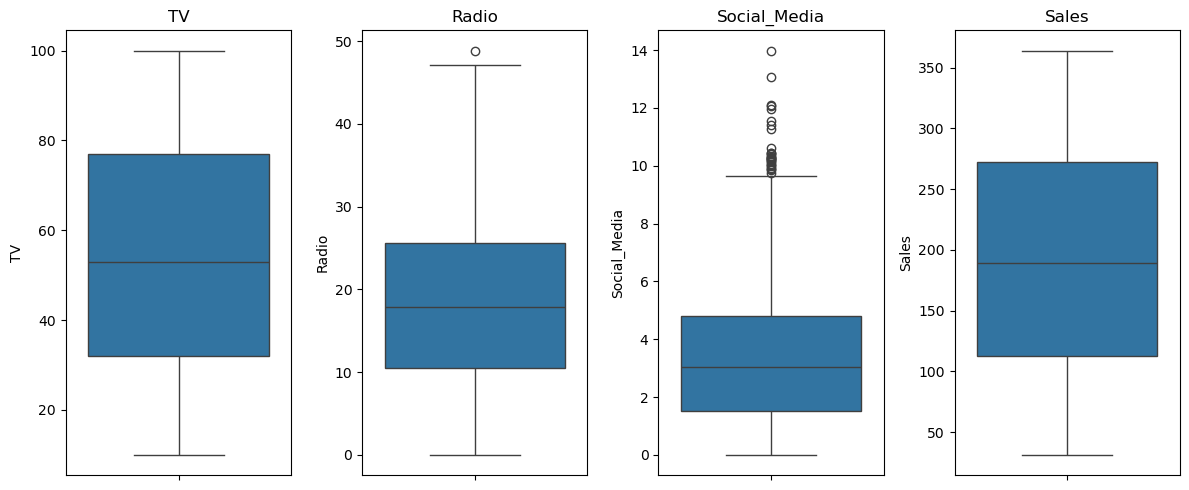

In [16]:
#Box Plot
plt.figure(figsize=(12,5))

for i, column in enumerate(df.columns,1):

    plt.subplot(1,4,i)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()

plt.show()

## Correlation Analysis

Correlation analysis is used to measure the strength and direction of the linear relationship between marketing channels and sales. The variable with the highest positive correlation with Sales will be selected as the predictor for the Simple Linear Regression model.

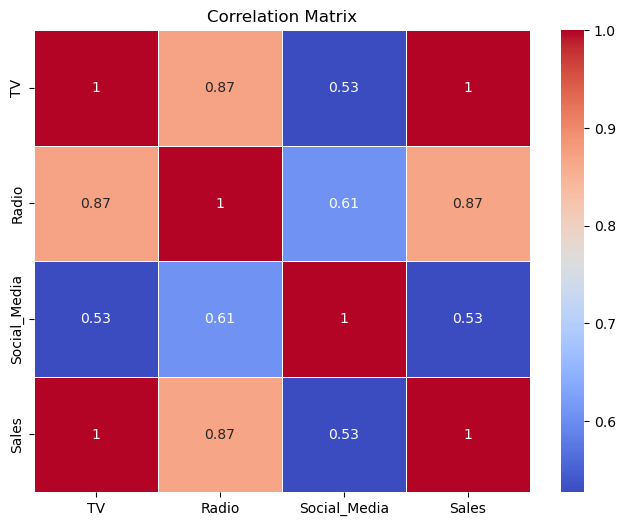

In [17]:
# Correlation Matrix
#The variable with the highest correlation will become our independent variable in the regression model.
plt.figure(figsize=(8,6))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix reveals that TV advertising has the strongest positive relationship with Sales (r = 0.9995), followed by Radio (r = 0.8686) and Social Media (r = 0.5274).

Therefore, TV advertising was selected as the independent variable for the regression model.

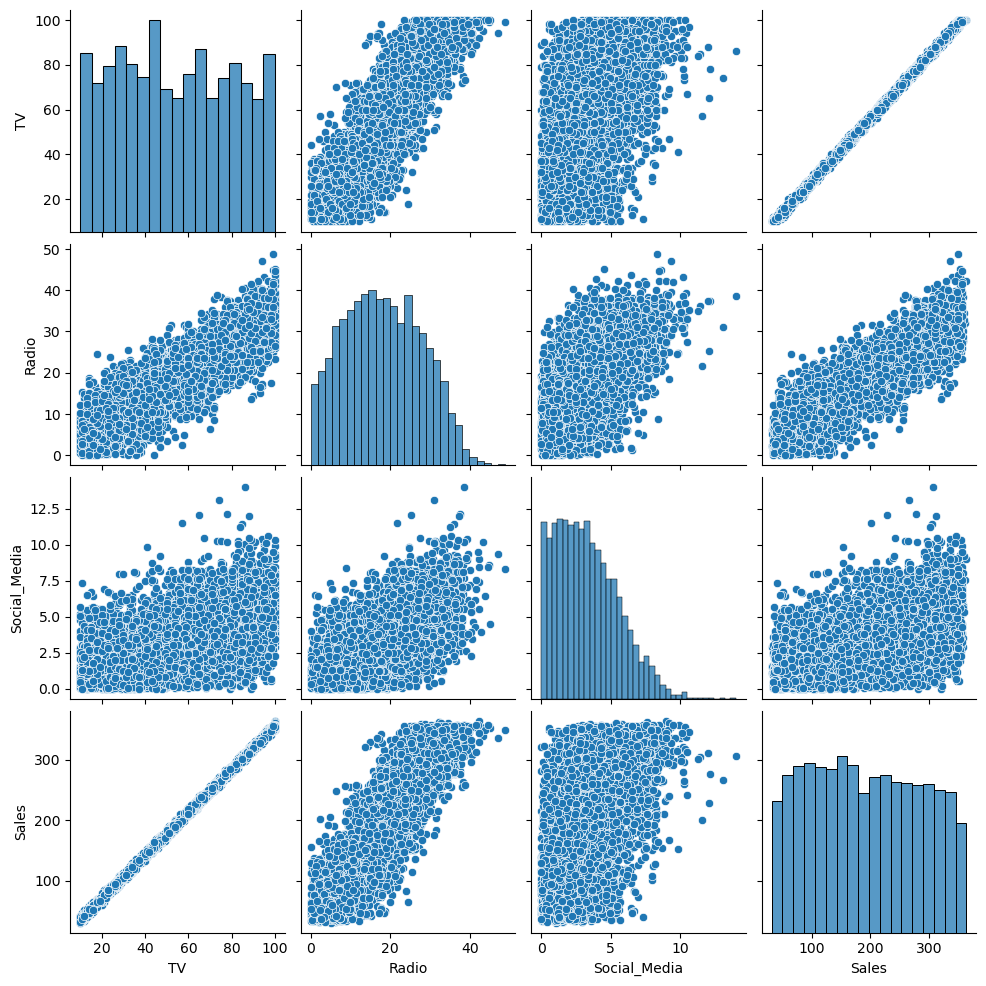

In [18]:
#Pairplot
#This visualizes every relationship in the dataset.
sns.pairplot(df)

plt.show()

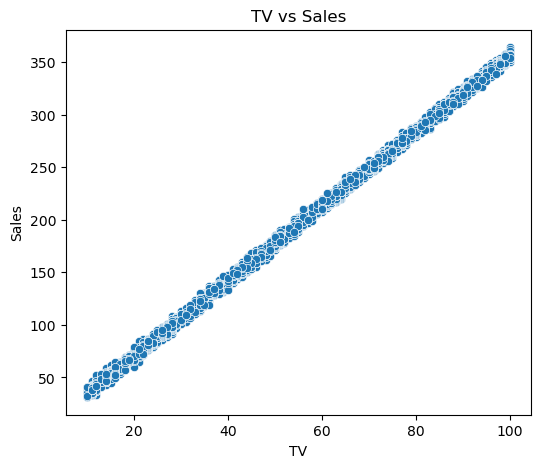

In [19]:
#Scatterplots of TV and Sales
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

plt.title("TV vs Sales")

plt.show()

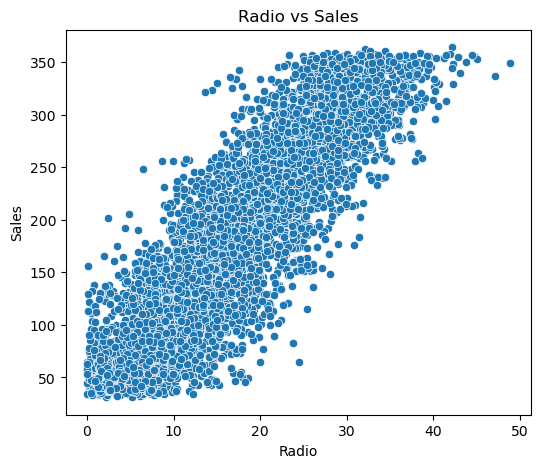

In [20]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

plt.title("Radio vs Sales")

plt.show()

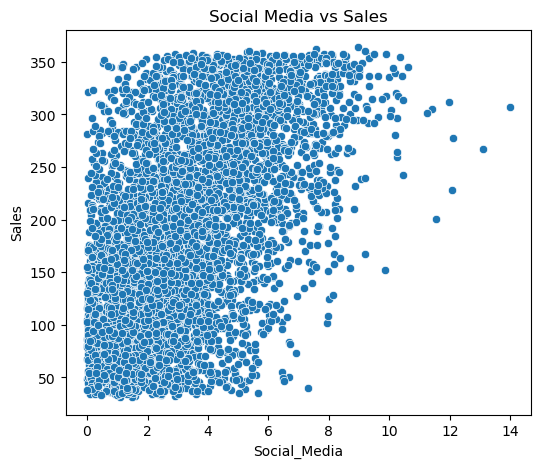

In [21]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='Social_Media',
    y='Sales'
)

plt.title("Social Media vs Sales")

plt.show()

In [22]:
#Find the Strongest Predictor
corr = df.corr()

corr["Sales"].sort_values(ascending=False)

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64

### Correlation Analysis

The correlation matrix indicates that all three marketing channels are positively associated with sales. TV advertising exhibits the strongest positive correlation with Sales (r = 0.9995), followed by Radio (r = 0.8686), while Social Media shows a moderate positive correlation (r = 0.5274).

Since TV has the highest correlation with Sales, it was selected as the independent variable for the Simple Linear Regression model.

In [23]:
#Building the Simple Linear Regression Model
#Defining Variables
# Independent variable
X = df[['TV']]

# Dependent variable
y = df['Sales']

In [24]:
#Spliting the Dataset
#We'll use 80% of the data for training and 20% for testing.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3636, 1)
Testing set: (910, 1)


In [26]:
#Adding constant
#In Ordinary Least Squares (OLS) regression, we need to include the intercept term.
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

In [27]:
#Fit the OLS Regression Model
model = sm.OLS(y_train, X_train_sm).fit()

In [28]:
#View the Model Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.598e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:47:52   Log-Likelihood:                -9110.9
No. Observations:                3636   AIC:                         1.823e+04
Df Residuals:                    3634   BIC:                         1.824e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1690      0.113     -1.500      0.1

Regression Equation
The fitted regression equation is:

Sales=−0.169+3.562(TV)

## Regression Equation

The fitted regression model is:

Sales = -0.169 + 3.562 × TV

This equation indicates that every one-unit increase in TV advertising expenditure is associated with an average increase of approximately 3.56 units in Sales.

### Interpretation of Coefficients

The intercept (-0.169) represents the estimated sales when TV advertising expenditure is zero. Since its p-value is greater than 0.05, it is not statistically significant.

The coefficient for TV advertising is 3.562 with a p-value less than 0.001, indicating that TV advertising has a statistically significant positive effect on Sales.

## Final Interpretation

Overall, the regression model demonstrates an excellent fit and confirms that TV advertising is a highly significant predictor of Sales. The very high R² value indicates that TV advertising explains nearly all the variability observed in Sales within this dataset. The model is statistically significant (p < 0.001), the regression assumptions related to normality and independence appear to be satisfied, and the estimated coefficient suggests that increasing TV advertising expenditure leads to a substantial increase in expected sales.

In [29]:
#Model Prediction and Performance Evaluation
#Preparing the Test Data
X_test_sm = sm.add_constant(X_test)

In [30]:
#Predict Sales
y_pred = model.predict(X_test_sm)

In [31]:
# Compare Actual and Predicted Values
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
497,55.261284,53.259714
3800,67.574904,71.069273
24,272.250108,266.974431
1918,195.102176,195.736192
142,273.960377,274.098255
1815,39.992087,39.012066
3357,147.150178,145.869424
2398,229.141912,224.231487
2345,222.696768,217.107664
3282,322.466797,320.403110


In [32]:
#Calculating Performance Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.9990115565052095
RMSE: 2.8832640545418053
MAE: 2.3108516081408697


### Model Performance

The regression model achieved an R² value of 0.999, indicating that approximately 99.9% of the variability in Sales is explained by TV advertising.

The RMSE of 2.88 and MAE of 2.31 indicate that prediction errors are very small, confirming excellent predictive accuracy.

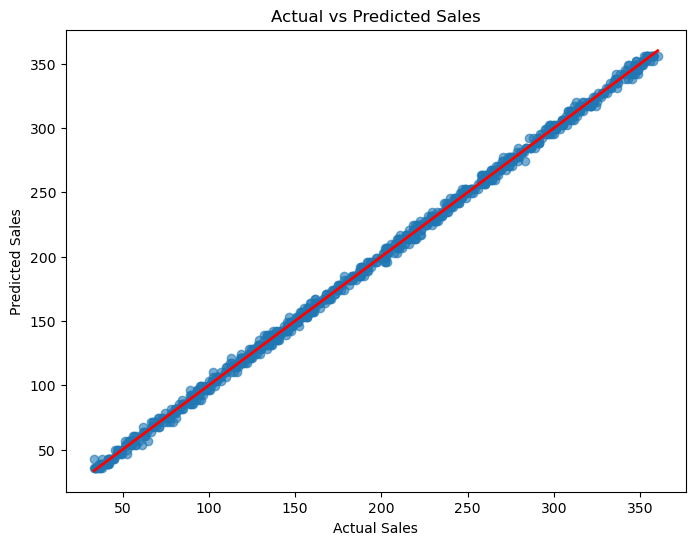

In [33]:
#Visualize Actual vs. Predicted Sales
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Model Evaluation
The model achieved an R² score of 0.9990, indicating that approximately 99.9% of the variation in Sales is explained by TV advertising expenditure. This demonstrates an excellent predictive performance.
The RMSE of 2.88 indicates that the model's prediction error is very low, demonstrating high predictive accuracy.
The RMSE of 2.88 indicates that the model's prediction error is very low, demonstrating high predictive accuracy.
# Actual vs Predicted Plot
The Actual vs Predicted plot demonstrates an almost perfect agreement between observed and predicted sales values. The clustering of observations around the 45° reference line confirms the excellent predictive capability of the regression model.

In [34]:
# Regression Diagnostic Tests
# Calculate residuals
residuals = y_test - y_pred

In [35]:
residuals

497     2.001571
3800   -3.494370
24      5.275677
1918   -0.634016
142    -0.137878
          ...   
3799    4.891412
2133   -3.349454
4410    4.160972
434     0.378053
178    -1.136323
Length: 910, dtype: float64

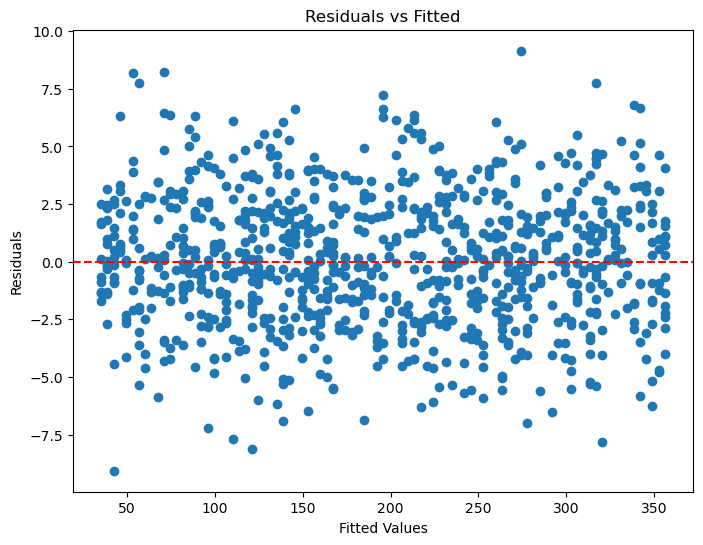

In [36]:
#Residual Plot (Linearity & Homoscedasticity)
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted")

plt.show()

### Interpretation

The residuals are randomly distributed around zero without any obvious pattern, indicating that the assumptions of linearity and homoscedasticity are satisfied.

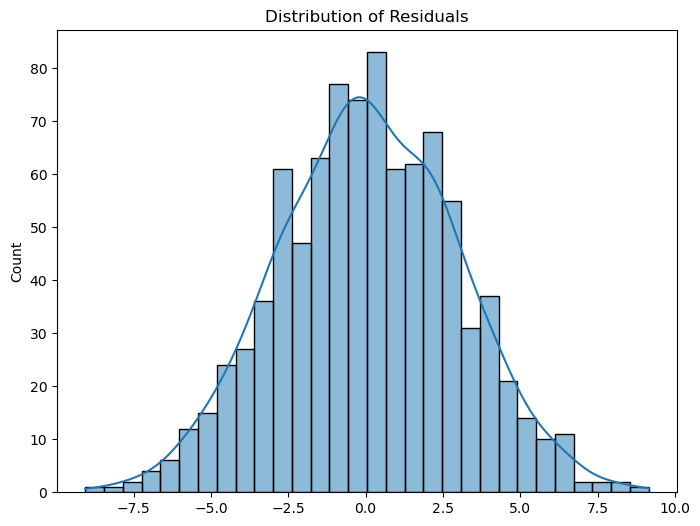

In [37]:
#Histogram of Residuals
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Residuals")

plt.show()

### Interpretation

The residuals appear approximately bell-shaped, suggesting that they are normally distributed.

<Figure size 800x600 with 0 Axes>

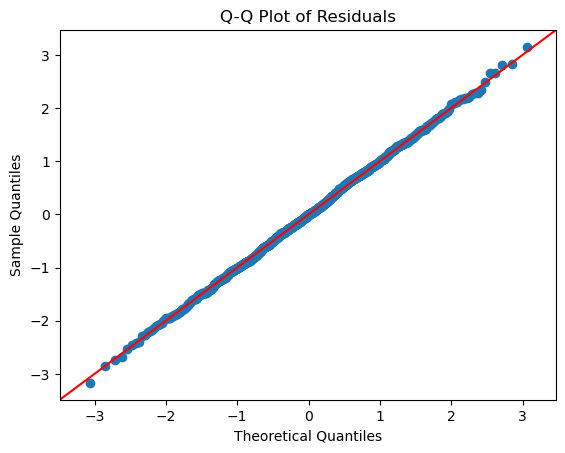

In [38]:
#Q–Q Plot
plt.figure(figsize=(8,6))

sm.qqplot(
    residuals,
    line='45',
    fit=True
)

plt.title("Q-Q Plot of Residuals")

plt.show()

### Interpretation

The points closely follow the reference line, indicating that the residuals satisfy the normality assumption.

Sales=−0.169+3.562(TV)

## Business Recommendation

The analysis demonstrates that TV advertising is the most effective marketing channel for increasing sales.

Organizations seeking to maximize marketing ROI should allocate a larger proportion of their advertising budget to TV campaigns while using Radio and Social Media as supporting channels.

# Conclusion

This study successfully applied Simple Linear Regression to evaluate the relationship between marketing expenditure and sales.

Exploratory Data Analysis showed that TV advertising had the strongest positive correlation with Sales (r = 0.9995).

The regression model

Sales = -0.169 + 3.562 × TV

explained approximately 99.9% of the variation in Sales.

The TV coefficient was statistically significant (p < 0.001), indicating that increased TV advertising expenditure significantly improves sales performance.

Model evaluation metrics (R² = 0.999, RMSE = 2.88, MAE = 2.31) confirmed excellent predictive performance.

Diagnostic plots indicated that the assumptions of linear regression were reasonably satisfied.

Overall, TV advertising is recommended as the primary marketing investment for maximizing return on investment.